Successfully loaded dataset with 1000 rows and 8 columns.

================ DATA VALIDATION ================
Missing Values Check:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64
Data validation complete. Clean dataset size: 1000

================ SUBJECT AVERAGE MARKS ================
Math Score     : 66.09
Reading Score  : 69.17
Writing Score  : 68.05

================ TOP 5 PERFORMING STUDENTS ================
     gender race/ethnicity parental level of education  Total Score  \
458  female        group E           bachelor's degree          300   
916    male        group E           bachelor's degree          300   
962  female        group E          associate's degree          300   
114  female        group E           bachelor's degree          299   

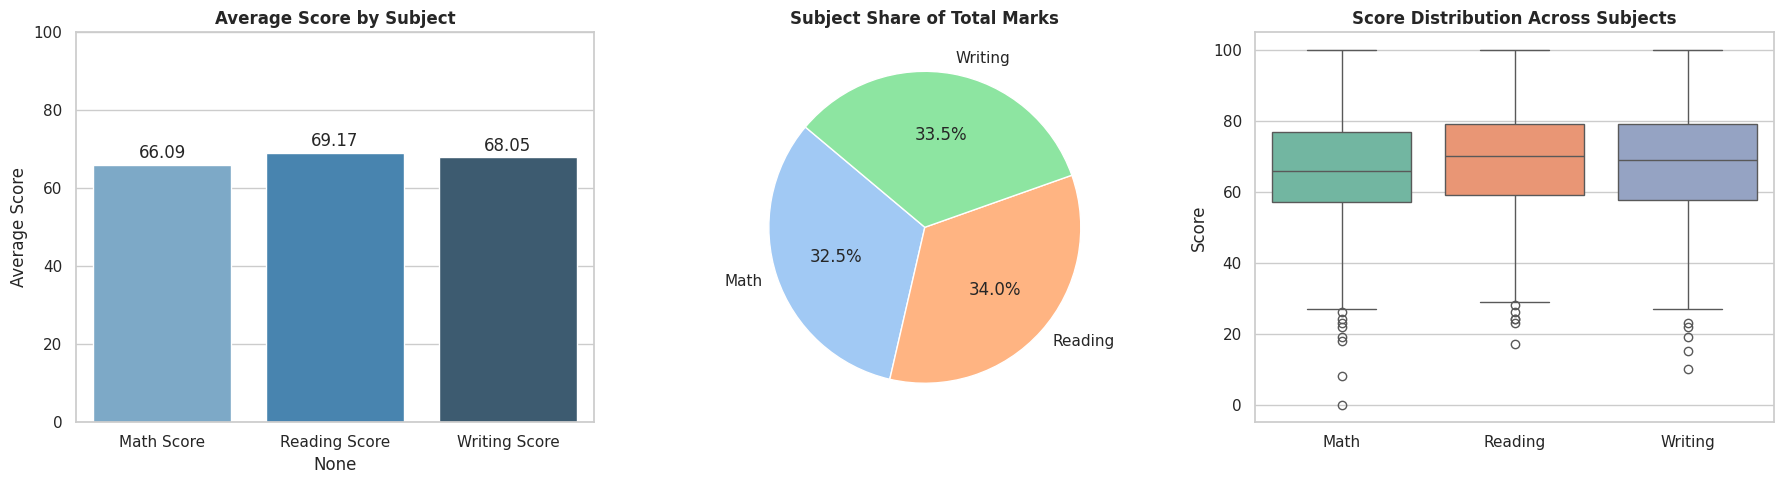

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

file_path = "/content/StudentsPerformance.csv"

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.\n")
except FileNotFoundError:
    print(f"Error: File not found at '{file_path}'. Please ensure the CSV file is uploaded.")

print("================ DATA VALIDATION ================")
print("Missing Values Check:")
print(df.isnull().sum())

df = df.dropna()

score_cols = ["math score", "reading score", "writing score"]
for col in score_cols:
    invalid_count = (df[col] < 0).sum()
    if invalid_count > 0:
        print(f"Removing {invalid_count} rows with negative values in {col}.")
        df = df[df[col] >= 0]

print("Data validation complete. Clean dataset size:", df.shape[0])
print("=================================================\n")

print("================ SUBJECT AVERAGE MARKS ================")
subject_averages = df[score_cols].mean()
for subject, avg in subject_averages.items():
    print(f"{subject.title():<15}: {avg:.2f}")

df["Total Score"] = df[score_cols].sum(axis=1)
df["Average Score"] = df[score_cols].mean(axis=1)
print("=======================================================\n")

top_5_students = df.nlargest(5, "Total Score")
print("================ TOP 5 PERFORMING STUDENTS ================")
print(top_5_students[["gender", "race/ethnicity", "parental level of education", "Total Score", "Average Score"]])
print("===========================================================\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    x=subject_averages.index.str.title(),
    y=subject_averages.values,
    ax=axes[0],
    hue=subject_averages.index.str.title(),
    palette="Blues_d",
    legend=False
)
axes[0].set_title("Average Score by Subject", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Average Score")
axes[0].set_ylim(0, 100)

for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points')

axes[1].pie(
    subject_averages.values,
    labels=[col.replace(" score", "").title() for col in score_cols],
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("pastel")
)
axes[1].set_title("Subject Share of Total Marks", fontsize=12, fontweight="bold")

sns.boxplot(
    data=df[score_cols],
    ax=axes[2],
    palette="Set2"
)
axes[2].set_title("Score Distribution Across Subjects", fontsize=12, fontweight="bold")
axes[2].set_xticks(range(len(score_cols)))
axes[2].set_xticklabels([col.replace(" score", "").title() for col in score_cols])
axes[2].set_ylabel("Score")

plt.tight_layout()
plt.show()